In [1]:
!pip install -q geopandas networkx spacy transformers bertopic umap-learn hdbscan sentence-transformers
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 128.8 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
!pip install "git+https://github.com/DS-20195/notebooks#egg=ds20195&subdirectory=lib"

  Cloning https://github.com/DS-20195/notebooks to /tmp/pip-install-jvf7_2nk/ds20195_c090817490e14cb4a998d417e0d2e942
  Running command git clone --filter=blob:none --quiet https://github.com/DS-20195/notebooks /tmp/pip-install-jvf7_2nk/ds20195_c090817490e14cb4a998d417e0d2e942
  Resolved https://github.com/DS-20195/notebooks to commit 2407d7e26fd0b88416427225eaf862c37f10ecc9
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 30.2 MB/s eta 0:00:00
  Created wheel for ds20195: filename=ds20195-0.0.1-py3-none-any.whl size=3688 sha256=65545b95a261cba33b099b1f83e852349cb2115344a4f0c554cf6e59abbc01cd
  Stored in directory: /tmp/pip-ephem-wheel-cache-dy43371p/wheels/24/47/8f/2780756f1cf00353089b7ee711e2b4c944ef371f5c37082c7d
Successfully built ds20195
  Attempting uninstall: gspread
    Found existing installation: gspread 6.2.1
    Uninstalling gspread-6.2.1:
      S

In [3]:
%config InlineBackend.figure_formats = ["svg"]
import base64
import io
import json
import re
import requests

import numpy as np
import pandas as pd; pd.set_option('display.max_rows', 500)
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

# NLP
import spacy
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from umap import UMAP

from shapely import Point
from ds20195 import google_sheets_credentials, generate_flow_sheet

# Week 5: Graphs, flows, and arms

### Fetching SIPRI flow data

This is a case study in real-world data munging.  There is extensive pre-processing to do to make the data useable.  We've chosen to show it to you in this notebook so that you get a realistic sense of the data challenges of working with a new dataset by reading through the notebook.  (Of course, you can also just click through it and everything should work.)

We're going to be working with a dataset from SIPRI (the Stockholm International Peace Research Institute) that tracks how arms and weaponry move around the world.

They have created a unit of weaponry called TIV ("trend indicator value"), which is an attempt to measure comparable amounts of **military capability**. It's some mix of cost and lethality that is designed to make it possible to compare arms flows across type and time.

For more on TIV, see the SIPRI fact sheet ["Measuring International Arms Transfers"](https://www.sipri.org/sites/default/files/files/FS/SIPRIFS1212.pdf).

SIPRI doesn't intend for users to grab their full dataset all at once, but we've figured out how to pull the whole CSV without any filters.  This might take a minute or more to run.  If it times out, try it again!

In [4]:
raw_data = requests.post(
    "https://atbackend.sipri.org/api/p/trades/trade-register-csv/",
    json={"filters": []},
).json()

Next, it turns out to be encoded in base 64, and we have to convert it to a more standard format.  Base 64 is a pretty nonstandard format, often used because it can encompass special characters, so it's important to notice the need to translate it or subsequent manipulations won't work as expected.

When you run the next cell, we'll examine the first 15 lines of the decoded file, which turns out to be a text header that needs to be chopped off the CSV for the rest of our work.  So we split at the carriage return (`split("\n")`) before continuing.

In [5]:
csv_lines = base64.b64decode(raw_data["bytes"]).decode("iso-8859-1").split("\n")
csv_lines[:15]

["Transfers of major conventional arms from All countries  to All countries . Deals with deliveries made for the year range 'Not specified' to 'Not specified' ",
 "A '?' in a column indicates uncertain data. The 'Number delivered' and the 'Year(s) of deliveries' refer only to deliveries in the selected year(s).",
 "An empty field for 'Number ordered' indicates that data is not yet available.",
 'SIPRI trend-indicator values (TIVs) are in millions.',
 "An empty field for 'SIPRI TIV for total order' indicates that data (on the number ordered and/or the TIV per unit) is not available.",
 "A '0' for 'SIPRI TIV of delivered weapons' indicates that the volume of deliveries is between 0 and 0.5 million SIPRI TIV; and an empty field indicates that no deliveries have been identified.",
 'Figures may not add up to stated totals due to the conventions of rounding.',
 'For the method used for the SIPRI TIV and explanations of the conventions; abbreviations and acronyms see <https://www.sipri.org/d

In [6]:
first_line_index = next(idx for idx, line in enumerate(csv_lines) if line.startswith("Recipient,"))
first_line_index

11

Let's make the dataframe!  It's got a huge amount of information about the weapons, when ordered, whether new or second-hand, and comments about the conflict context.

In [7]:
arms_df = pd.read_csv(io.StringIO("\n".join(csv_lines[first_line_index:])))
arms_df.to_csv("fulldata.csv")
arms_df

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00
29912,Zimbabwe,China,1990,?,2.0,NaN,J-7,fighter aircraft,2,NaN,1991,New,FT-7BZ version,9.00,18.00,18.00
29913,Zimbabwe,Italy,1967,?,20.0,?,Model-56 105mm,towed gun,20,?,1967,New,Supplier uncertain,0.45,9.00,9.00
29914,Zimbabwe,France,1977,?,3.0,NaN,Cessna-337/O-2,light aircraft,3,NaN,1977,New,NaN,0.35,1.05,1.05


In [8]:
arms_df.groupby(["Recipient", "Supplier", "Year of order"]).count()

Number ordered   .1  \
Recipient            Supplier           Year of order                           
ANC (South Africa)*  Soviet Union       1988           0               1    1   
Afghanistan          Belarus            2018           0               1    0   
                     Bosnia-Herzegovina 2009           0               1    0   
                                        2012           1               1    1   
                     Brazil             2013           0               1    0   
...                                                   ..             ...  ...   
unknown recipient(s) United States      1990           1               1    1   
                                        1995           0               1    0   
                                        2010           0               1    1   
                                        2018           2               2    2   
                                        2025           0               0    0   

                                                       Weapon designation  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Weapon description  \
Recipient            Supplier           Year of order                       
ANC (South Africa)*  Soviet Union       1988                            1   
Afghanistan          Belarus            2018                            1   
                     Bosnia-Herzegovina 2009                            1   
                                        2012                            1   
                     Brazil             2013                            1   
...                                                                   ...   
unknown recipient(s) United States      1990                            1   
                                        1995                            1   
                                        2010                            1   
                                        2018                            2   
                                        2025                            1   

                                                       Number delivered   .2  \
Recipient            Supplier           Year of order                          
ANC (South Africa)*  Soviet Union       1988                          1    1   
Afghanistan          Belarus            2018                          1    0   
                     Bosnia-Herzegovina 2009                          1    1   
                                        2012                          1    0   
                     Brazil             2013                          1    1   
...                                                                 ...  ...   
unknown recipient(s) United States      1990                          1    1   
                                        1995                          1    0   
                                        2010                          1    1   
                                        2018                          2    2   
                                        

We can narrow down what we're looking at.  The next cell lets you toggle between looking for (a) [Mi-17s](https://en.wikipedia.org/wiki/Mil_Mi-17) that do not come from Russia/USSR, or (b) second-hand weapons.  Try it both ways.

In [9]:
# arms_df[(arms_df["Weapon designation"] == "Mi-17") & (arms_df["Supplier"] != "Russia") & (arms_df["Supplier"] != "Soviet Union")]
arms_df[arms_df["status"] == "Second hand"]

,Recipient,Supplier,Year of order,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29906,Zimbabwe,South Africa,1972,?,1.0,NaN,AL-60,light transport aircraft,1,NaN,1973,Second hand,Second-hand,0.10,0.10,0.10
29909,Zimbabwe,Spain,1988,?,1.0,?,C-212,transport aircraft,1,NaN,1990,Second hand,Second-hand; C-212-200 version,1.52,1.52,1.52
29910,Zimbabwe,South Africa,1976,?,1.0,NaN,BN-2 Islander,light transport aircraft,1,NaN,1977,Second hand,Second-hand,0.24,0.24,0.24
29911,Zimbabwe,China,1984,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00


What other statuses are possible?

In [10]:
arms_df["status"].unique()

array(['Second hand', 'New', 'Second hand but modernized'], dtype=object)

In [11]:
arms_df["Weapon designation"].value_counts()

,count
Weapon designation,
aircraft engine,439
ship engine,397
vehicle engine,283
Mi-17,241
M-113,227
...,...
Promoter,1
Akash,1
Pinaka 214mm,1


# Mapping transfers


Visualizing the SIPRI dataset presents several problems:

* Recipients and suppliers are _usually_ countries, but this does not always hold. Notice that the dataset includes non-state actors (such as the [Houthi rebels](https://en.wikipedia.org/wiki/Houthis) or the [Mujahideen](https://en.wikipedia.org/wiki/Afghan_mujahideen)).  We will need one lat/long location per actor, so we'll try to find an appropriate capital city.
* This dataset goes back to the 1940s, so it references countries that no longer exist (such as [Biafra](https://en.wikipedia.org/wiki/Biafra) and [Yugoslavia](https://en.wikipedia.org/wiki/Yugoslavia)).
* There is some variability in names. For instance, "Ivory Coast" and "Cote d'Ivoire" are two different names for the same country.

For visualization purposes, we'll map these special cases to the nearest equivalent contemporary states. For instance, we'll map South Vietnam to Vietnam; Saigon (the former capital of South Vietnam) is now Ho Chi Minh City (the current capital of Vietnam). We'll exclude flows to or from entities that do not clearly correspond to a single region (for instance, the United Nations).

The following dictionary associating SIPRI states to modern states was made by hand and represents a lot of labor!  You should at least glance through it to get a sense of some of the nitty-gritty involved here.  Note the comments at the end about non-obvious decisions (a good practice when cleaning data, so you'll know what you were thinking later on!) and the explicit list of exceptions.

In [12]:
capitals_map = {
    "ANC (South Africa)*": "South Africa",
    "Anti-Castro rebels (Cuba)*": "Cuba",
    "Amal (Lebanon)*": "Lebanon",
    "Armas (Guatemala)*": "Guatemala",
    "Contras (Nicaragua)*": "Nicaragua",
    "Darfur rebels (Sudan)*": "Sudan",
    "ELF (Ethiopia)*": "Ethiopia",
    "EPLF (Ethiopia)*": "Ethiopia",
    "FRELIMO (Portugal)*": "Portugal",
    "Haiti rebels*": "Haiti",
    "Hezbollah (Lebanon)*": "Lebanon",
    "House of Representatives (Libya)*": "Libya",
    "Houthi rebels (Yemen)*": "Yemen",
    "Indonesia rebels*": "Indonesia",
    "Khmer Rouge (Cambodia)*": "Cambodia",
    "Kurdistan Regional Government (Iraq)*": "Iraq",
    "LF (Lebanon)*": "Lebanon",
    "LRA (Uganda)*": "Uganda",
    "LTTE (Sri Lanka)*": "Sri Lanka",
    "Libya GNC": "Libya",
    "Libya HoR*": "Libya",
    "HoR (Libya)*": "Libya",
    "Congo": "Congo (Brazzaville)",
    "DR Congo": "Congo (Kinshasa)",
    "MNLF (Philippines)*": "Philippines",
    "MPLA (Portugal)*": "Portugal",
    "MTA (Myanmar)*": "Myanmar",
    "Micronesia": "Federated States of Micronesia",
    "Mujahedin (Afghanistan)*": "Afghanistan",
    "NLA (Macedonia)*": "North Macedonia",
    "NTC (Libya)*": "Libya",
    "Northern Alliance (Afghanistan)*": "Afghanistan",
    "Northern Cyprus": "Cyprus",
    "PAIGC (Portugal)*": "Portugal",
    "PIJ (Israel/Palestine)*": "Israel",
    "PKK (Turkiye)*": "Turkey",
    "PLO (Israel)*": "Israel",
    "PRC (Israel/Palestine)*": "Israel",
    "Pathet Lao (Laos)*": "Laos",
    "Provisional IRA (UK)*": "United Kingdom",
    "RPF (Rwanda)*": "Rwanda",
    "RUF (Sierra Leone)*": "United Kingdom",
    "SLA (Lebanon)*": "Lebanon",
    "SNA (Somalia)*": "Somalia",
    "SPLA (Sudan)*": "Sudan",
    "Southern rebels (Yemen)*": "Yemen",
    "Syria rebels*": "Syria",
    "Turkiye": "Turkey",
    "UAE": "United Arab Emirates",
    "UIC (Somalia)*": "Somalia",
    "UNITA (Angola)*": "Angola",
    "Ukraine Rebels*": "Ukraine",
    "United States": "United States of America",
    "United Wa State (Myanmar)*": "Myanmar",
    "Viet Minh (France)*": "France",
    "Viet Nam": "Vietnam",
    "ZAPU (Zimbabwe)*": "Zimbabwe",
    "GUNT (Chad)*": "Chad",
    "FAN (Chad)*": "Chad",
    "FMLN (El Salvador)*": "El Salvador",
    "Gambia": "The Gambia",
    "Lebanon Palestinian rebels*": "Lebanon",
    "Cote d'Ivoire": "Ivory Coast",
    "Bahamas": "The Bahamas",
    "FNLA (Angola)*": "Angola",
    "Cabo Verde": "Cape Verde",
    "Timor-Leste": "East Timor",
    "Saint Vincent": "Saint Vincent and the Grenadines",
    "Guinea-Bissau": "Guinea Bissau",
    "South Vietnam": "Vietnam",  # Saigon is now Ho Chi Minh City
    "Viet Cong (South Vietnam)*": "Vietnam",
    "Hamas (Palestine)*": "Palestine",
    "Soviet Union": "Russia",
    "NATO**": "Belgium",  # NATO headquarters in Brussels
    'European Union**': "Belgium",  # EU headquarters in Brussels
    "OSCE**": "Austria",  # secretariat in Vienna
    "Yemen Arab Republic (North Yemen)": "Yemen",  # same capital as Yemen (Sanaa)
    "North Yemen": "Yemen",  # same capital as Yemen (Sanaa)
    "Czechoslovakia": "Czechia",  # same capital as the modern Czech Republic (Prague)
    "Yugoslavia": "Serbia",  # same capital as Serbia (Belgrade)
    "East Germany (GDR)": "Germany",  # for large-scale flow maps, approximate East Berlin with Berlin
    "Western Sahara": "Morocco",  # largely under Moroccan occupation
}

exclude_flows = {
    "nan",
    "unknown rebel group*",
    "unknown recipient(s)",
    'unknown supplier(s)',
    "United Nations**",
    "Regional Security System**",
    "African Union**",
    '0.25',
    '3',
}


Even more exceptions!  These lat/longs were added by hand.

In [13]:
# (long, lat) coordinates for capitals of entities not included in the places shapefile.
# Several of these entities are countries that no longer exist.
extra_capitals = {
    "Biafra": ("Enugu", 7.5139, 6.4483),  # 1967 capital (now part of Nigeria)
    "Bosnia-Herzegovina": ("Sarajevo", 18.4131, 43.8563),
    "South Yemen": ("Aden", 45.0176, 12.7906),
    "Katanga": ("Lubumbashi", 27.5026, -11.6876),
    "South Sudan": ("Juba",  31.5825, 4.8539),
    "Palestine": ("East Jerusalem", 35.217018, 31.771959),
    "Aruba": ("Oranjestad", -70.0353, 12.5227),
}

...and put into a format that's suitable for adding to the capitals list we're making.  Note the CRS (coordinate reference system) specified.

In [14]:
extra_capitals_gdf = gpd.GeoDataFrame(
    [
        {
            "adm0name": entity,
            "name": capital,
            "longitude": long,
            "latitude": lat,
            "geometry": Point(long, lat),
        }
        for entity, (capital, long, lat) in extra_capitals.items()
    ],
    crs="epsg:4326",
).set_index("adm0name")
extra_capitals_gdf

,name,longitude,latitude,geometry
adm0name,,,,
Biafra,Enugu,7.513900,6.448300,POINT (7.5139 6.4483)
Bosnia-Herzegovina,Sarajevo,18.413100,43.856300,POINT (18.4131 43.8563)
South Yemen,Aden,45.017600,12.790600,POINT (45.0176 12.7906)
Katanga,Lubumbashi,27.502600,-11.687600,POINT (27.5026 -11.6876)
South Sudan,Juba,31.582500,4.853900,POINT (31.5825 4.8539)
Palestine,East Jerusalem,35.217018,31.771959,POINT (35.21702 31.77196)
Aruba,Oranjestad,-70.035300,12.522700,POINT (-70.0353 12.5227)


Next we're going to read in a simple shapefile from a cartographic society that gives locations for major world cities and identifies which ones are capital cities.  Note even more special-case handling:  some countries have more than one capital!  (South Africa famously has three.)

In [15]:
places_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip")
capitals_gdf = places_gdf[places_gdf["adm0cap"] == 1].set_index("adm0name")
# force each nation to have exactly one capital
capitals_gdf = capitals_gdf[~capitals_gdf["name"].isin(["Sucre", "Yamoussoukro", "Bloemfontein", "Pretoria"])][["name", "latitude", "longitude", "geometry"]]
capitals_gdf = gpd.GeoDataFrame(pd.concat([capitals_gdf, extra_capitals_gdf]), crs="epsg:4326")

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.16.0, but is running against 8.11.0. Runtime failure is likely !
  return ogr_read(


In [16]:
capitals_gdf.tail(100)

,name,latitude,longitude,geometry
adm0name,,,,
Albania,Tirana,41.327541,19.818883,POINT (19.81888 41.32754)
Armenia,Yerevan,40.183097,44.511606,POINT (44.51161 40.1831)
Azerbaijan,Baku,40.397218,49.860271,POINT (49.86027 40.39722)
Cambodia,Phnom Penh,11.551976,104.914689,POINT (104.91469 11.55198)
Bolivia,La Paz,-16.496028,-68.151931,POINT (-68.15193 -16.49603)
Benin,Cotonou,6.401954,2.518045,POINT (2.40435 6.36298)
Bulgaria,Sofia,42.685295,23.314708,POINT (23.31471 42.6853)
Belarus,Minsk,53.901923,27.564681,POINT (27.56468 53.90192)
Bhutan,Thimphu,27.472986,89.639014,POINT (89.63901 27.47299)


Hopefully this dataset gives you many ideas of things you could analyze.

Here are just a few...
* Study arms flows connected to a protracted conflict (e.g., Israel–Palestine)
* Pick a small window of time, like 1-2 years, and do a deeper look at that snapshot.
* The USSR collapsed circa 1991.  Do you see an immediate impact on arms flows?
* Consider second-hand arms sales.  How does weaponry "trickle down" from rich exporters to first and then second recipients.
* How does the popularity and regionality of a particular weapon (e.g., the Mi-17) change over time?

## By year

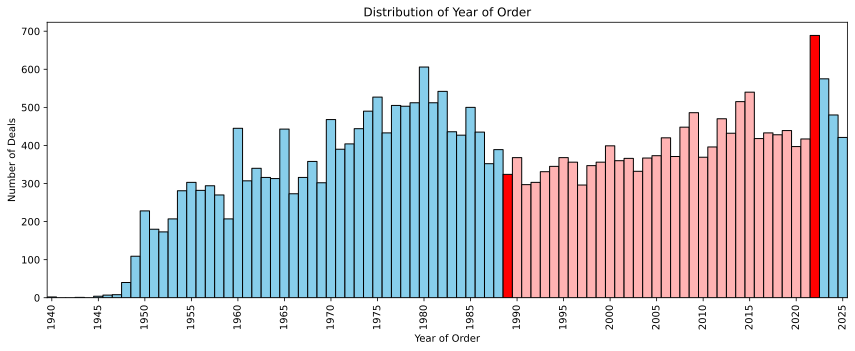

In [17]:
# Drop missing or NaN years, convert to int if needed
years = arms_df["Year of order"].dropna().astype(int)

# Get unique years for full range, for ticks and highlighting
min_year, max_year = years.min(), years.max()

# Define bins so each year is a bin of size 1
bins = np.arange(min_year, max_year + 2, 1)  # right edge exclusive

fig, ax = plt.subplots(figsize=(12, 5))
n, bins_, patches = ax.hist(years, bins=bins, color='skyblue', edgecolor='black', align='mid')

# Years 1990-2024 (between 1989 and 2025) in light red
# Years 1989 and 2025 in dark red
for patch, left_edge, right_edge in zip(patches, bins_[:-1], bins_[1:]):
    bin_year = int(left_edge)
    if 1990 <= bin_year <= 2021:
        patch.set_facecolor('#ffb3b3') # light red
    elif bin_year == 1989 or bin_year == 2022:
        patch.set_facecolor('red') # dark red

# Set title and labels
ax.set_title("Distribution of Year of Order")
ax.set_xlabel("Year of Order")
ax.set_ylabel("Number of Deals")

# Only show ticks for years divisible by five (ending in 0 or 5)
tick_years = [year for year in bins_[:-1] if int(year) % 5 == 0 or int(year) % 5 == 5]
tick_centers = [y + 0.5 for y in tick_years]
ax.set_xticks(tick_centers)
ax.set_xticklabels([str(int(y)) for y in tick_years], rotation=90)
ax.set_xlim(bins_[0], bins_[-1])

plt.tight_layout()
plt.show()

# Building a graph

To make a visual that shows the movement, a natural data object is a **graph**, in the sense of discrete mathematics.  A graph is made up of vertices (also called nodes), with some of them connected by edges.  The edges can be weighted, and can have a direction.  So a flow can be represented as a weighted directed edge from vertex $v$ to vertex $w$.

We'll set this up with a dataframe giving only a limited number of attributes per state, then a secondary dataframe grouping by year.

In [18]:
flowmap_arms_df = arms_df[~arms_df["Supplier"].isin(exclude_flows) & ~arms_df["Recipient"].isin(exclude_flows)].rename(
    columns={
        "Year of order": "order_year",
        "Recipient": "recipient",
        "Supplier": "supplier",
        "SIPRI TIV for total order": "order_sipri_tiv"
    }
)
# Convert the order_year column to datetime (year)
flowmap_arms_df["order_year"] = pd.to_datetime(flowmap_arms_df["order_year"], errors="coerce", format="%Y")

flowmap_arms_df_og = flowmap_arms_df[
    (flowmap_arms_df["order_year"] >= pd.to_datetime("1981")) & (flowmap_arms_df["order_year"] <= pd.to_datetime("1983"))
]
flowmap_arms_df_new = flowmap_arms_df[
    (flowmap_arms_df["order_year"] >= pd.to_datetime("2022")) & (flowmap_arms_df["order_year"] <= pd.to_datetime("2025"))
]

In [19]:
flowmap_arms_df

,recipient,supplier,order_year,,Number ordered,.1,Weapon designation,Weapon description,Number delivered,.2,Year(s) of delivery,status,Comments,SIPRI TIV per unit,order_sipri_tiv,SIPRI TIV of delivered weapons
0,Afghanistan,Russia,2010-01-01,?,6.0,?,Mi-17,transport helicopter,6,NaN,2011,Second hand,Probably second-hand; Mi-17V1 version; bought ...,2.90,17.40,17.40
1,Afghanistan,Russia,2004-01-01,?,4.0,NaN,Mi-17,transport helicopter,4,?,2005,Second hand,Second-hand; aid; Mi-8MTV version,2.90,11.60,11.60
2,Afghanistan,Soviet Union,1960-01-01,?,50.0,?,BM-13 132mm,multiple rocket launcher,50,?,1960; 1961,Second hand,Second-hand,0.08,4.00,4.00
3,Afghanistan,Soviet Union,1978-01-01,?,500.0,?,T-55,tank,500,?,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986...,Second hand,Second-hand; aid,0.50,250.00,250.00
4,Afghanistan,Soviet Union,1987-01-01,?,40.0,?,MiG-21MF,fighter aircraft,40,?,1987; 1988; 1989; 1990,Second hand,Second-hand; probably incl some MiG-21UM,4.28,171.20,171.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29911,Zimbabwe,China,1984-01-01,?,2.0,NaN,FT-5,(armed) trainer aircraft,2,NaN,1986,Second hand,Probably Second-hand,1.50,3.00,3.00
29912,Zimbabwe,China,1990-01-01,?,2.0,NaN,J-7,fighter aircraft,2,NaN,1991,New,FT-7BZ version,9.00,18.00,18.00
29913,Zimbabwe,Italy,1967-01-01,?,20.0,?,Model-56 105mm,towed gun,20,?,1967,New,Supplier uncertain,0.45,9.00,9.00
29914,Zimbabwe,France,1977-01-01,?,3.0,NaN,Cessna-337/O-2,light aircraft,3,NaN,1977,New,NaN,0.35,1.05,1.05


# NLP
Now let's move toward a clearer picture of the "comments" column. Upon investigation, the comments could yield insights into two aspects of arms traids. The prevalence of aid and the purpose for which arms are meant to be used. Aid is straightfoward to detect: it simply involves the presence of "aid" as a comment (sometimes with additional nuance, but the underlying approach is the same). 

The purpose for which the arms are transferred is a bit more nuanced. Often, comments will include a phrase describing the intended use of the weapons traded as "for ...". In many cases, the link is simply another weapons system - for example, when a type of missile is bought "for use with [insert missile launcher name]." Yet in other cases, these may describe the agency or types of operations a system is planned for. Despite these differences, we can again use regex to extract these for-clauses, though with added details to make sense of edge cases such as the presence of multiple for-clauses.

## Aid

In [20]:
# Define aid
flowmap_arms_df["aid"] = flowmap_arms_df["Comments"].str.contains(r"\baid\b", case=False, na=False)

In [21]:
# Inspect if aid is correctly extracted (cycle through different random_states to see different rows); or set "aid" to False
pd.set_option('display.max_colwidth', None)
aid_sample_df = flowmap_arms_df[flowmap_arms_df["aid"] == False].sample(n=30, random_state=42)[["recipient", "supplier", "order_year", "Comments", "aid"]]
display(aid_sample_df)
# Reset max_colwidth to default (50)
pd.reset_option('display.max_colwidth')

,recipient,supplier,order_year,Comments,aid
5175,Colombia,South Korea,2013-01-01,KRW34 b ($31 m) deal; designed in Colombia and produced in South Korea for Colombia; Colombian designation Punta Soldado,False
28193,United Kingdom,Germany,2021-01-01,For modernization of 148 Challenger-2 tanks to Challenger-3; produced under licence in UK,False
19759,Philippines,Turkiye,2020-01-01,For modification of 6 AIFV (ACV-300) armoured personnel carriers to infantry fighting vehicles,False
17431,New Zealand,United Kingdom,1985-01-01,Probably second-hand; for Leander frigates,False
21546,Saudi Arabia,Ukraine,2020-01-01,NaN,False
23972,Sri Lanka,Israel,1999-01-01,NaN,False
12483,Ireland,United Kingdom,1988-01-01,Second-hand; $12 m deal,False
20926,Romania,United States,2023-01-01,M-1110 version,False
10965,India,Soviet Union,1967-01-01,For Foxtrot (Kalvari) submarines,False
15018,Libya,Portugal,1978-01-01,NaN,False


## "For..." Extraction (Regex)
The second step consists of extracting the stated reasons for the arms trade. These are described using "for ..." in the comments section. We can use simple regex rules to extract these, though note we have to be careful about the presence of multiple such for-clauses in the comments. Setting up these regexes and edge cases required careful qualitative inspection of the data and multiple rounds of iterative testing/quality assurance.

In [22]:
len(flowmap_arms_df[flowmap_arms_df["Comments"].str.contains(r"\bfor\b", case=False, na=False)])

9550

In [23]:
# Inspect cases where "for" appears as a standalone word in the "Comments" column (prompt engineering)
pd.set_option('display.max_colwidth', None)
for_comments_sample_df = flowmap_arms_df[flowmap_arms_df["Comments"].str.contains(r"\bfor\b", case=False, na=False)].sample(n=30, random_state=42)[["recipient", "supplier", "order_year", "Comments"]]
display(for_comments_sample_df)
# Reset max_colwidth to default (50)
pd.reset_option('display.max_colwidth')

,recipient,supplier,order_year,Comments
15225,Lithuania,United States,2016-01-01,For 2 NASAMS SAM systems from Norway
4900,China,France,1986-01-01,For 2 Type-052 (Luhu) and 1 Type-051B (Luhai) destroyers; and 2 Type-054 (Jiangkai-1) and 8 Type-053H3 (Jiangwei-2) frigates produced in China and for modernization of 3 Type-051 (Luda-1 and/or Luda-2) destroyers; probably assembled/produced under licence in China incl as Type-345; for use with Crotale EDIR (Chinese designation HQ-7) SAM system
28295,United Kingdom,Germany,2019-01-01,Part of GBP183 m ($238 m) deal; for UK company for training UK armed forces in 'MFTS' programme; UK designation Jupiter HT-1
25014,Taiwan,United States,1982-01-01,For F-5E combat aircraft; AIM-9J version
18037,North Korea,China,1973-01-01,For Soho frigate and Huangfen missile boats and for coastal defence
18242,Norway,United Kingdom,1989-01-01,Part of $18 m deal (incl modernization of 10 Norwegian Sea Kings to Mk-43B version); Sea King Mk-43B version; for SAR
24513,Sweden,United Kingdom,1992-01-01,Second-hand; for use as depot ship; Swedish designation Belos-3
5491,Croatia,Israel,2017-01-01,HRK94 m ($14.8 m) deal; UT-30MK2 version for 6 AMV infantry fighting vehicles from Finland
25749,Thailand,United Kingdom,2008-01-01,16RK-270 (6700hp) diesel engine; for 1 Endurance landing ship from Singapore
7297,Egypt,China,1976-01-01,Exchanged for several MiG-23 fighter aircraft used by China for development of Chinese fighter aircraft


Numerous comments include mentions of countries and their adjectives, which may refer to the weapons' origins, manufacturing country, or contexts of deployment. These may clutter our topic model, which simply picks up on recurring words and could identify country names as topics simply due to their frequent recurrence. 

As a result, my extraction of for-clauses below includes a data-cleaning step with SpaCy's named entity recogntion (NER) capacities. Passing each comment to SpaCy slightly increases runtime, but let's us filter out words that are tagged as ``GPE`` (geopolitical: countries/cities/regions) or ``NORP`` (nationalities/demonyms/adjectives).

In [24]:
# Define regexes and helpers to extract individual for-clauses
nlp = spacy.load("en_core_web_sm")

FOR_CLAUSE_START_RE = re.compile(r"\bfor\b", flags=re.IGNORECASE)
SEMICOLON_RE = re.compile(r";")
TRAILING_CONNECTOR_RE = re.compile(r"\s+and\s*$", flags=re.IGNORECASE)
WHITESPACE_RE = re.compile(r"\s+")

# Entities: GPE (geopolitical: countries/cities/regions); NORP (nationalities/demonyms/adjectives).
GEO_OR_DEMONYM_LABELS = frozenset({"GPE", "NORP"})


def strip_gpe_norp_tokens(text):
    '''Drop tokens spaCy assigns as GPE or NORP.'''
    doc = nlp(text)
    kept = [tok.text for tok in doc if tok.ent_type_ not in GEO_OR_DEMONYM_LABELS]
    return WHITESPACE_RE.sub(" ", " ".join(kept)).strip()


def clean_reason_text(reason):
    '''Normalize one extracted for-clause; remove NORP/GPE-labelled words via spaCy NER.'''
    if not isinstance(reason, str):
        return None

    reason = WHITESPACE_RE.sub(" ", reason).strip(" ,.;:")
    reason = TRAILING_CONNECTOR_RE.sub("", reason).strip(" ,.;:")
    if not reason:
        return None

    reason = strip_gpe_norp_tokens(reason).strip(" ,.;:")
    return reason or None


def extract_for_reasons(comment):
    '''Return each standalone for-clause up to the next for, semicolon, or comment end.'''
    if not isinstance(comment, str):
        return []

    matches = list(FOR_CLAUSE_START_RE.finditer(comment))
    reasons = []

    for idx, match in enumerate(matches):
        start = match.end()
        next_for_start = matches[idx + 1].start() if idx + 1 < len(matches) else len(comment)
        semicolon_match = SEMICOLON_RE.search(comment, pos=start, endpos=next_for_start)
        end = semicolon_match.start() if semicolon_match else next_for_start

        reason = clean_reason_text(comment[start:end])
        if reason:
            reasons.append(reason)

    return reasons


In [25]:
# Extract clauses from "Comments" column; takes about 1min to run
flowmap_arms_df["for_reasons"] = flowmap_arms_df["Comments"].apply(extract_for_reasons)

# Keep repeated runs tidy by replacing any earlier reason_* columns.
old_reason_cols = [col for col in flowmap_arms_df.columns if re.fullmatch(r"reason_\d+", str(col))]
flowmap_arms_df = flowmap_arms_df.drop(columns=old_reason_cols)

max_reasons = flowmap_arms_df["for_reasons"].str.len().max()
max_reasons = 0 if pd.isna(max_reasons) else int(max_reasons)
reason_column_names = [f"reason_{idx}" for idx in range(1, max_reasons + 1)]

reason_cols_df = pd.DataFrame(
    flowmap_arms_df["for_reasons"].tolist(),
    index=flowmap_arms_df.index,
    columns=reason_column_names,
)

flowmap_arms_df = pd.concat([flowmap_arms_df, reason_cols_df], axis=1)

In [26]:
# Inspect the extracted for-clauses
reason_preview_cols = [col for col in flowmap_arms_df.columns if re.fullmatch(r"reason_\d+", str(col))]
rows_with_reasons = flowmap_arms_df["for_reasons"].str.len().gt(0).sum()

print(f"Rows with at least one extracted for-clause: {rows_with_reasons:,}")
print(f"Maximum number of for-clauses in one comment: {len(reason_preview_cols)}")

preview_cols = ["recipient", "supplier", "order_year", "Comments", *reason_preview_cols]
preview_pool = flowmap_arms_df[flowmap_arms_df["for_reasons"].str.len().gt(0)]

# Prioritize multi-clause examples because they are the hardest cases to validate by eye.
multi_clause_preview = preview_pool[preview_pool["for_reasons"].str.len().gt(1)]
if len(multi_clause_preview) > 0:
    display(multi_clause_preview[preview_cols].sample(n=min(10, len(multi_clause_preview)), random_state=42))
else:
    display(preview_pool[preview_cols].sample(n=min(10, len(preview_pool)), random_state=42))

Rows with at least one extracted for-clause: 9,496
Maximum number of for-clauses in one comment: 4


,recipient,supplier,order_year,Comments,reason_1,reason_2,reason_3,reason_4
22294,Singapore,Israel,1992-01-01,For 6 MGB-62 (Victory) corvettes from FRG; for...,6 MGB-62 ( Victory ) corvettes from FRG,use with Barak SAM,None,None
3887,Canada,Thailand,2024-01-01,Second-hand; for civilian company for training...,civilian company,training of and other forces,None,None
24480,Sweden,United States,1979-01-01,For target-towing and EW training; operated by...,target - towing and EW training,armed forces,None,None
16125,Mexico,Brazil,2001-01-01,Part of $230-250 m deal; incl for SIGINT; main...,SIGINT,anti - narcotics operations,None,None
10346,India,France,2017-01-01,EUR7.8 b deal (incl EUR5.2 b for aircraft EUR1...,aircraft EUR1.8 b,spare parts and EUR710 m,armament,None
13405,Japan,United States,1978-01-01,For frigates and destroyers; UGM-84 version fo...,frigates and destroyers,submarines and AGM-84 version,P-3C anti - submarine aircraft,None
10857,India,Israel,2000-01-01,For modernization of 1 Viraat aircraft carrier...,modernization of 1 Viraat aircraft carrier,3 Brahmaputra frigates produced in,use with Barak-1 SAM system,None
6224,Denmark,United Kingdom,1982-01-01,For 4 Thetis frigates and 7 Flyvefisken missil...,4 Thetis frigates and 7 Flyvefisken missile bo...,modernization of 1 Beskytteren patrol ship,None,None
28260,United Kingdom,United States,1983-01-01,Second-hand; owned and operated by civilian co...,EW training and target - towing,armed forces,None,None
2699,Bolivia,Canada,1977-01-01,Second-hand; T-33AN (CT-133) version; partly e...,6 second - hand P-51D combat aircraft,private company,None,None


## BERTopic

Although many algorithms/approaches to topic modeling exist, I have chosen to use the embeddings-based BERTopic for this project ([awesome documentation here](https://maartengr.github.io/BERTopic/index.html)). 

The reasons for that are:
- the module's ability to render comments of any length/complexity into a high-dimensional embedding representation, which should flatten out differences in comment complexities/lengths; 
- the possibility of tuning any of the steps used in the pipeline (e.g., dimension reduction and clustering) to suit the short length of comments overall; and
- the host of functionalities included in the BERTopic package that make working with and refining topics relatively straightforward.

In [27]:
# Long format: one row per extracted for-clause, keyed by original dataframe index 
# (merge back with flowmap_arms_df on row_id vs index)
clause_docs_df = flowmap_arms_df[["for_reasons"]].copy()
clause_docs_df["row_id"] = clause_docs_df.index
clause_docs_df = clause_docs_df.explode("for_reasons", ignore_index=True).rename(columns={"for_reasons": "clause_text"})
clause_docs_df = clause_docs_df.dropna(subset=["clause_text"])
clause_docs_df = clause_docs_df[clause_docs_df["clause_text"].str.strip().ne("")]

print(f"Clause-level documents for BERTopic: {len(clause_docs_df):,}")
print(f"Unique deal rows contributing at least one clause: {clause_docs_df['row_id'].nunique():,}")

clause_docs_df.head()

Clause-level documents for BERTopic: 10,008
Unique deal rows contributing at least one clause: 9,496


,clause_text,row_id
0,training of crews and instructors in,0
7,26 L-39 trainer aircraft from,7
8,Mi-24 combat helicopters,8
19,S-125 air - defence systems,19
40,reconnaissance role before delivery,40


In [54]:
# Guided topic modeling allows us to supply seed-word lists to bias clusters toward hypotheses
seed_topic_list = [
    ["modernization"],
]

There are different models available to convert our text data into embeddings. Here, I have chosen a version of BERTopic's baseline (sentence-transformers/all-MiniLM-L6-v2) that was fine-tuned to military text data ([model card](https://huggingface.co/bbmb/deep-learning-for-embedding-model-ssilwal-qpham6_army_doc)).

In [55]:
# Set N of topics we aim to have. I set 20 for now for experimentation, but might shift to a smaller number 
# to easy the integration and analysis with network data. Too many clusters might be messy there.
N_TOPICS = 20

# Define our UMAP/HDBSCAN instances for dimension reduction and clustering, respectively
umap_model_army = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model_army = HDBSCAN(min_cluster_size=5, min_samples=3, prediction_data=True)

# Load the model from Hugging Face: finetuned from MiniLM on Army doctrinal QA-style text
embedding_army_doc = SentenceTransformer("bbmb/deep-learning-for-embedding-model-ssilwal-qpham6_army_doc")

topic_model_army_doc = BERTopic(
    embedding_model=embedding_army_doc,
    seed_topic_list=seed_topic_list,
    umap_model=umap_model_army,
    hdbscan_model=hdbscan_model_army,
    nr_topics=N_TOPICS,
    calculate_probabilities=True,
    verbose=False,
)

topics_army, probs_army = topic_model_army_doc.fit_transform(docs)

clause_docs_df["topic_army_doc"] = topics_army
if probs_army is not None:
    clause_docs_df["topic_prob_army_doc"] = np.asarray(probs_army).max(axis=1).ravel()

# Show our topics
display(topic_model_army_doc.get_topic_info())
# display(topic_model_army_doc.get_document_info(docs).head(10))

clause_docs_df[["row_id", "clause_text", "topic_army_doc", "topic_prob_army_doc"]].head(10)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,879,-1_in_and_produced_aircraft,"[in, and, produced, aircraft, modernization, f...","[use in, use in, infantry fighting vehicles an..."
1,0,5771,0_aircraft_from_combat_frigates,"[aircraft, from, combat, frigates, produced, i...","[2 missile boats produced in, 6 K-8 trainer / ..."
2,1,1023,1_training_police_guard_border,"[training, police, guard, border, forces, nati...","[training, training in, training in]"
3,2,448,2_sam_with_mm_systems,"[sam, with, mm, systems, use, guns, sa, system...","[use with SA-4 SAM systems, use with SA-2 SAM ..."
4,3,351,3_fac_opv_mrl_ifv,"[fac, opv, mrl, ifv, bmp, as, frg, apc, reduce...","[FAC, FAC, 2 FAC from]"
5,4,280,4_vip_transport_as_use,"[vip, transport, as, use, military, ship, gove...","[VIP transport, VIP transport, VIP transport]"
6,5,218,5_sar_dhabi_abu_mp,"[sar, dhabi, abu, mp, homeland, bophuthatswana...","[SAR, SAR, SAR]"
7,6,203,6_parts_only_spare_spares,"[parts, only, spare, spares, engines, armament...","[spare parts only, spare parts only ), spare p..."
8,7,192,7_coast_guard_coastal_defence,"[coast, guard, coastal, defence, systems, mari...","[coast guard, coast guard, coast guard]"
9,8,179,8_nuclear_warheads_under_control,"[nuclear, warheads, under, control, with, laun...",[missiles with nuclear warheads ( under contro...


,row_id,clause_text,topic_army_doc,topic_prob_army_doc
0,0,training of crews and instructors in,0,0.127879
7,7,26 L-39 trainer aircraft from,0,0.265612
8,8,Mi-24 combat helicopters,0,1.000000
19,19,S-125 air - defence systems,-1,0.077924
40,40,reconnaissance role before delivery,1,0.495818
54,55,MiG-21F combat aircraft,0,1.000000
56,57,police,-1,0.158265
59,60,training,1,0.067081
60,61,S-75 air - defence systems,0,0.315445
62,63,20 EMB-314 trainer / combat aircraft from,0,0.380146


### Refine coarse topics

We saw that our topic model created one very large cluster and a series of smaller ones. To break up this skewed distribution somewhat, let's clean up our topics and do a second-pass `BERTopic` that subdivides the largest topic found earlier for better distribution of topics. Having more and smaller clusters should allow for a more nuanced analysis of edges in arms trading.


In [44]:
# Parameters

army_topic_info = topic_model_army_doc.get_topic_info()


def _army_topics_from_topic_column(*topic_numbers: int) -> tuple[int, ...]:
    """Every id must appear in army_topic_info['Topic'] (BERTopic get_topic_info output)."""
    allowed = set(army_topic_info["Topic"].astype(int).tolist())
    out: list[int] = []
    for t in topic_numbers:
        ti = int(t)
        if ti not in allowed:
            raise ValueError(
                f"Topic {ti} is not in get_topic_info()['Topic']. "
                f"Allowed ids: {sorted(allowed)!r}"
            )
        out.append(ti)
    return tuple(out)


def _validate_topic_column_subset(topic_ids: list[int] | tuple[int, ...], *, label: str) -> None:
    allowed = set(army_topic_info["Topic"].astype(int).tolist())
    missing = sorted(set(topic_ids) - allowed)
    if missing:
        raise ValueError(
            f"{label} contains ids not in get_topic_info()['Topic']: {missing}. "
            f"Allowed: {sorted(allowed)!r}"
        )


ORIGINAL_N_TOPICS = int(N_TOPICS)

# Define IDs of clauses belonging to the N largest coarse topics (excluding -1)
SUBDIVIDE_TOP_N_PARENT_TOPICS = (
    1 
)

# Merge: each tuple lists ids from the "Topic" column that should be merged into one topic (order of tuples = merge order).
ARMY_TOPIC_MERGE_GROUPS = [
    _army_topics_from_topic_column(7, 8, 9),
]

# Excluded coarse topics — each id must appear in army_topic_info["Topic"] before merges (re-check after merges if ids change).
TOPICS_EXCLUDED_FROM_WHALE_SELECTION: list[int] = []
_validate_topic_column_subset(TOPICS_EXCLUDED_FROM_WHALE_SELECTION, label="TOPICS_EXCLUDED_FROM_WHALE_SELECTION")

merged_specs: list[list[int]] = [list(t) for t in ARMY_TOPIC_MERGE_GROUPS if len(t) > 1]
n_merged_topic_slots = sum(len(g) - 1 for g in merged_specs)

for grp in merged_specs:
    topic_model_army_doc.merge_topics(docs, [grp])
    topics_post_merge, probs_post_merge = topic_model_army_doc.transform(docs)
    clause_docs_df["topic_army_doc"] = topics_post_merge
    if probs_post_merge is not None:
        clause_docs_df["topic_prob_army_doc"] = np.asarray(probs_post_merge).max(axis=1).ravel()

# topic_model_army_doc.get_topic_info() # Show updated "Topic" column

n_topics_removed = len(TOPICS_EXCLUDED_FROM_WHALE_SELECTION)


In [ ]:
# Select whale clauses from coarse topic_army_doc assignments

eligible = clause_docs_df.loc[clause_docs_df["topic_army_doc"].ne(-1), "topic_army_doc"]
counts = eligible.value_counts()

for tid in TOPICS_EXCLUDED_FROM_WHALE_SELECTION:
    counts = counts.drop(labels=tid, errors="ignore")

target_army_parent_topics = counts.nlargest(SUBDIVIDE_TOP_N_PARENT_TOPICS).index.tolist()

army_whale_mask = clause_docs_df["topic_army_doc"].isin(target_army_parent_topics)
army_whale_docs = clause_docs_df.loc[army_whale_mask, "clause_text"].astype(str).tolist()

N_REFINE = max(2, n_topics_removed + 1 + n_merged_topic_slots)
# N_REFINE = 8  # uncomment to define how many topics we want to break the 'large' cluster into

print(
    f"[Big split] coarse topic_army_doc={target_army_parent_topics}; "
    f"n_clauses={int(army_whale_mask.sum())}; planned N_REFINE={N_REFINE}; "
    f"excluded_topics={n_topics_removed}; merged_topic_slots={n_merged_topic_slots}"
)



[Big split] coarse topic_army_doc=[0]; n_clauses=6793; planned N_REFINE=4; removed_budget_topics=3


In [51]:
# Train nested BERTopic on whale clauses only
_umap_army_whale_split = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric="cosine", random_state=43)
_hdb_army_whale_split = HDBSCAN(min_cluster_size=5, min_samples=3, prediction_data=True)

topic_model_army_whale_split = BERTopic(
    embedding_model=embedding_army_doc,
    umap_model=_umap_army_whale_split,
    hdbscan_model=_hdb_army_whale_split,
    nr_topics=N_REFINE,
    calculate_probabilities=True,
    verbose=False,
)

topics_army_whale_split, probs_army_whale_split = topic_model_army_whale_split.fit_transform(army_whale_docs)


In [52]:
# Attach subdivision outputs & preview.
clause_docs_df["topic_army_doc_subdivide"] = np.nan
clause_docs_df.loc[army_whale_mask, "topic_army_doc_subdivide"] = topics_army_whale_split

clause_docs_df["topic_army_doc_subdivide_prob"] = np.nan
if probs_army_whale_split is not None:
    clause_docs_df.loc[army_whale_mask, "topic_army_doc_subdivide_prob"] = np.asarray(probs_army_whale_split).max(
        axis=1
    ).ravel()

clause_docs_df["topic_army_doc_composite"] = clause_docs_df["topic_army_doc"]
_parent_army_labels = clause_docs_df.loc[army_whale_mask, "topic_army_doc"].astype(int).astype(str)
_child_army_labels = clause_docs_df.loc[army_whale_mask, "topic_army_doc_subdivide"].astype(int).astype(str)
clause_docs_df.loc[army_whale_mask, "topic_army_doc_composite"] = _parent_army_labels + "_s" + _child_army_labels

display(topic_model_army_whale_split.get_topic_info())

clause_docs_df.loc[
    army_whale_mask, ["topic_army_doc", "topic_army_doc_subdivide", "topic_army_doc_composite"]
].head(15)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,442,-1_aircraft_combat_16_from,"[aircraft, combat, 16, from, 5e, and, in, mig,...","[F-16 combat aircraft, F-16 combat aircraft, F..."
1,0,6095,0_aircraft_from_combat_in,"[aircraft, from, combat, in, produced, frigate...","[combat aircraft, 6 K-8 trainer / combat aircr..."
2,1,149,1_coast_guard_coastal_defence,"[coast, guard, coastal, defence, maritime, sys...","[coast guard, coast guard, coast guard]"
3,2,107,2_use_as_ship_airline,"[use, as, ship, airline, military, on, carrier...","[use as training ship, use as training ship, u..."


,topic_army_doc,topic_army_doc_subdivide,topic_army_doc_composite
7,0,0.0,0_s0
8,0,0.0,0_s0
19,0,0.0,0_s0
54,0,0.0,0_s0
60,0,0.0,0_s0
62,0,0.0,0_s0
67,0,0.0,0_s0
79,0,0.0,0_s0
104,0,0.0,0_s0
105,0,0.0,0_s0
